# Exploratory Data Analysis

Goal: Understand customer behavior and transaction patterns in an e-commerce dataset.

Focus areas:
- Customer activity
- Revenue trends
- Repeat vs one-time users

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
# --- PAYMENTS_AGG ---
payments_agg = (
    payments
    .groupby("order_id", as_index = False)
    .agg({
        "payment_value": "sum"
    })
)

In [8]:
payments_agg.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [9]:
# --- ORDER_ITEMS_AGG ---
order_items_agg = (
    order_items
    .groupby("order_id", as_index = False)
    .agg({
        "order_item_id": "count",
        "price": "sum",
        "freight_value": "sum"
    })
    .rename(columns = {
        "order_item_id": "num_items",
        "price": "total_price",
        "freight_value": "total_freight"
    })
)

In [10]:
order_items_agg.head()

,order_id,num_items,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [11]:
# --- FINAL DATASET ---
df = (
    orders
    .merge(order_items_agg, on = "order_id", how = "left")
    .merge(payments_agg, on = "order_id", how = "left")
    .merge(customers, on = "customer_id", how = "left")
)

In [12]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,num_items,total_price,total_freight,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [13]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [14]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,num_items,total_price,total_freight,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02


In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique Orders:", df["order_id"].nunique())

Rows: 99441
Columns: 17
Unique Orders: 99441


In [16]:
# # --- MISSING VALUES ---
# missing = (
#     df.isnull()
#     .sum()
#     .sort_values(ascending=False)
# )

# missing = missing[missing > 0]

# missing

In [17]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing %": missing_pct
}).sort_values(by="missing %", ascending=False)

missing_df[missing_df["missing_count"] > 0]

,missing_count,missing %
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
total_freight,775,0.779357
num_items,775,0.779357
total_price,775,0.779357
order_approved_at,160,0.160899
payment_value,1,0.001006


### Missing Values

- Some fields contain missing values, especially in delivery-related timestamps.
- These are expected (e.g., undelivered or cancelled orders).
- For now, no imputation is required as they are not critical for revenue analysis.

In [18]:
monthly_revenue = (
    df.groupby("order_month")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

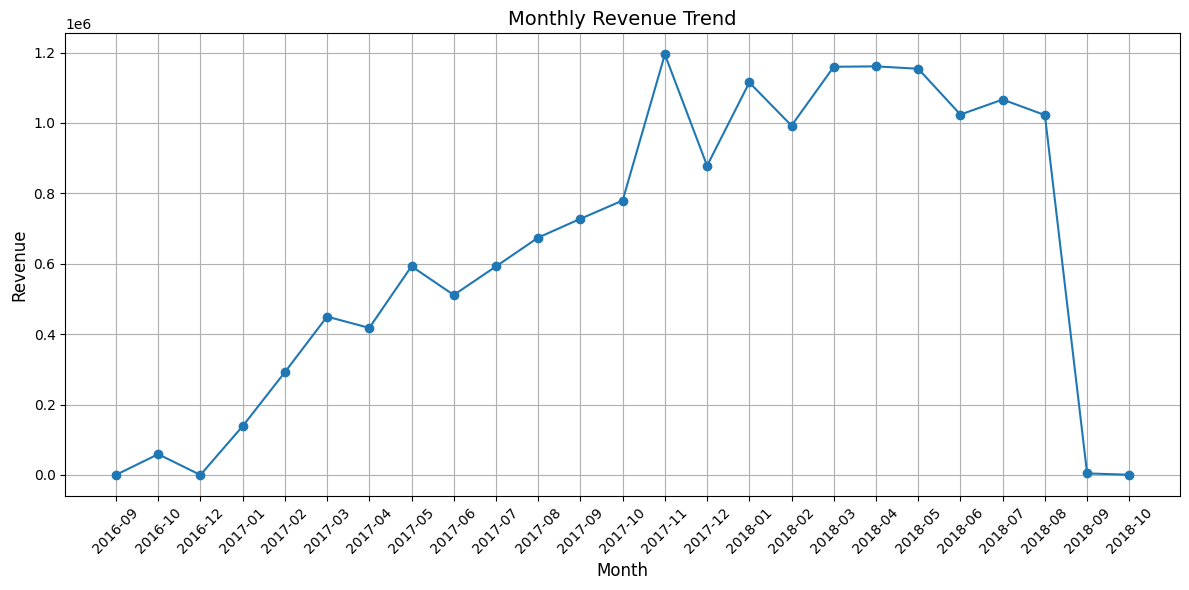

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["payment_value"],
    marker='o'
)

plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Revenue Trend Observations

- Revenue shows fluctuations across months, indicating seasonality in customer purchases.
- Some months show clear spikes, possibly due to promotions or festive periods.
- Overall trend suggests growing activity over time, but not strictly linear.

In [20]:
peak_month = monthly_revenue.loc[
    monthly_revenue["payment_value"].idxmax()
]

peak_month

order_month        2017-11
payment_value    1194882.8
Name: 13, dtype: object

- Peak revenue observed in November 2017, indicating highest customer activity.

In [21]:
# --- ORDERS PER CUSTOMER ---
orders_per_customer = (
    df
    .groupby("customer_unique_id", as_index=False)
    .agg({
        "order_id": "nunique"
    })
    .rename(columns={
        "order_id": "num_orders"
    })
)

orders_per_customer.head()

,customer_unique_id,num_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [22]:
# --- DISTRIBUTION ---
order_dist = (
    orders_per_customer["num_orders"]
    .value_counts()
    .sort_index()
)

order_dist

num_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

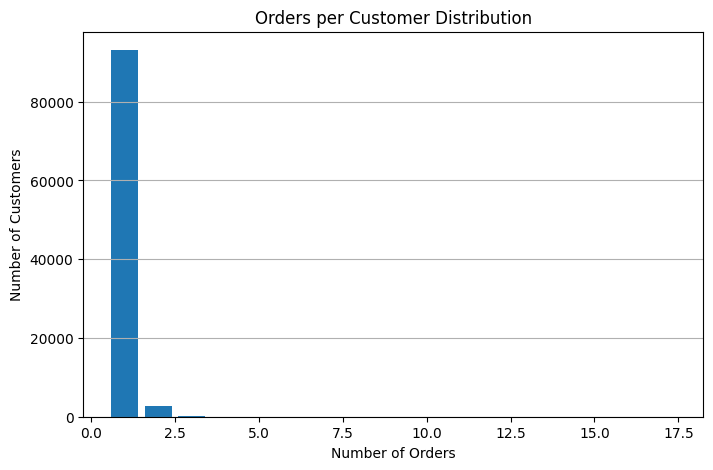

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(order_dist.index, order_dist.values)

plt.title("Orders per Customer Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.grid(axis='y')
plt.show()

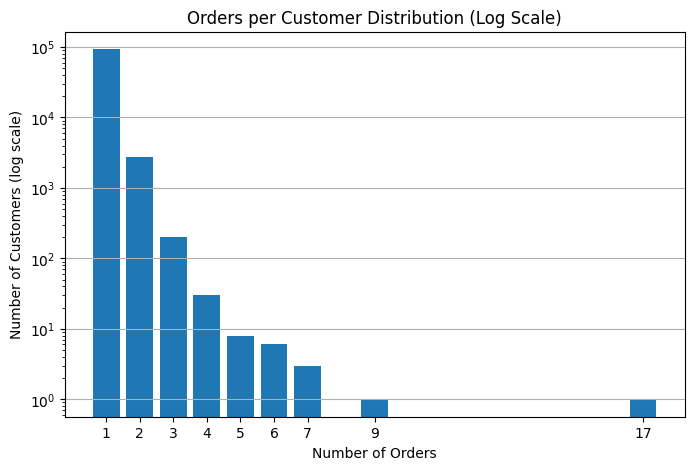

In [24]:
# --- Log Scale graph for better visibility ---

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(order_dist.index, order_dist.values)

plt.yscale("log")  # for log scaling on Y-axis
plt.xticks(order_dist.index) # for integer ticks on X-axis

plt.title("Orders per Customer Distribution (Log Scale)")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers (log scale)")

plt.grid(axis='y')
plt.show()

### Customer Purchase Behavior

- Distribution is highly skewed — most customers make only one purchase
- Very small fraction of users are repeat buyers (2+ orders)
- Indicates poor retention and heavy reliance on new customer acquisition

In [25]:
# --- REVENUE PER CUSTOMER ---
revenue_per_customer = (
    df
    .groupby("customer_unique_id", as_index=False)
    .agg({
        "payment_value": "sum"
    })
    .rename(columns={
        "payment_value": "total_spent"
    })
)

revenue_per_customer.head()

,customer_unique_id,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [26]:
revenue_per_customer.sort_values(by="total_spent", ascending=False).head()

,customer_unique_id,total_spent
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31


In [27]:
# --- SORT CUSTOMERS BY SPENDING ---
revenue_per_customer = revenue_per_customer.sort_values(
    by="total_spent",
    ascending=False
).reset_index(drop=True)

In [28]:
# --- ADD PERCENTILE ---
revenue_per_customer["percentile"] = (
    (revenue_per_customer.index + 1) / len(revenue_per_customer)
)

In [29]:
# --- CUMULATIVE REVENUE ---
revenue_per_customer["cum_revenue"] = (
    revenue_per_customer["total_spent"].cumsum()
)

total_revenue = revenue_per_customer["total_spent"].sum()

revenue_per_customer["cum_revenue_pct"] = (
    revenue_per_customer["cum_revenue"] / total_revenue
)

In [30]:
# Top 20% contribution
top_20_cutoff = int(0.2 * len(revenue_per_customer))

top_20_revenue = (
    revenue_per_customer
    .sort_values(by="total_spent", ascending=False)
    .head(top_20_cutoff)["total_spent"]
    .sum()
)

total_revenue = revenue_per_customer["total_spent"].sum()

print(f"{top_20_revenue / total_revenue:.2f}")

0.54


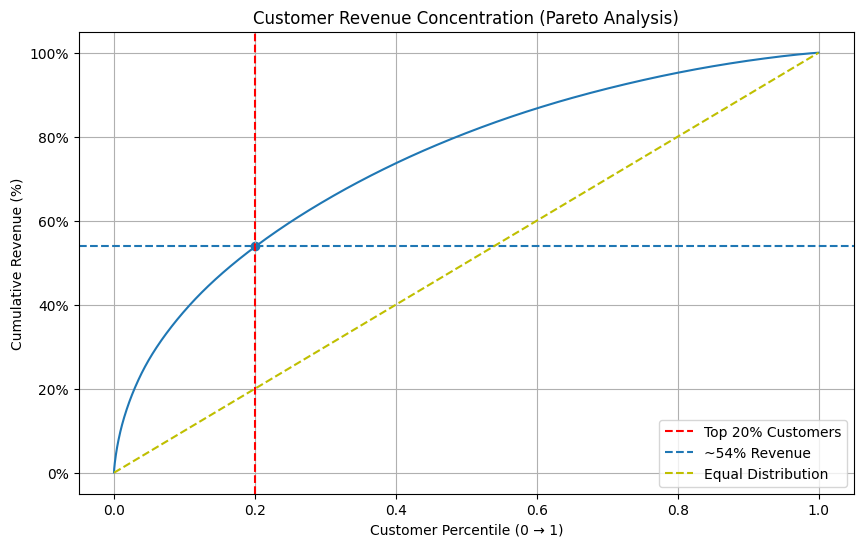

In [31]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.plot(
    revenue_per_customer["percentile"],
    revenue_per_customer["cum_revenue_pct"]
)

# Highlight 20% and 80%
plt.axvline(x=0.2, linestyle="--", color='r', label="Top 20% Customers")
plt.axhline(y=0.54, linestyle="--", label="~54% Revenue")

# Mark the intersection
plt.scatter([0.2], [0.54])

# Perfect equality line
plt.plot([0,1], [0,1], linestyle="--", color = 'y', label="Equal Distribution")
plt.title("Customer Revenue Concentration (Pareto Analysis)")
plt.xlabel("Customer Percentile (0 → 1)")
plt.ylabel("Cumulative Revenue (%)")

plt.legend()
plt.grid(True)
plt.show()

### Revenue Concentration (Pareto Analysis)

- Top 20% of customers contribute ~54% of total revenue
- Revenue distribution is significantly skewed compared to equal distribution
- Business is highly dependent on a small segment of high-value customers
- Retention strategies targeting these users can have disproportionate impact

In [34]:
# --- REFERENCE DATE ---
reference_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(reference_date)

2018-10-18 17:30:18


In [35]:
# --- RFM BASE ---
rfm = (
    df
    .groupby("customer_unique_id", as_index=False)
    .agg({
        "order_purchase_timestamp": "max",
        "order_id": "nunique",
        "payment_value": "sum"
    })
)

rfm.columns = [
    "customer_unique_id",
    "last_purchase",
    "frequency",
    "monetary"
]

In [36]:
# --- RECENCY ---
rfm["recency"] = (reference_date - rfm["last_purchase"]).dt.days

In [37]:
rfm = rfm.drop(columns=["last_purchase"])

In [38]:
rfm.describe()

,frequency,monetary,recency
count,96096.000000,96096.000000,96096.000000
mean,1.034809,166.592492,288.735691
std,0.214384,231.428332,153.414676
min,1.000000,0.000000,1.000000
25%,1.000000,63.120000,164.000000
50%,1.000000,108.000000,269.000000
75%,1.000000,183.530000,398.000000
max,17.000000,13664.080000,773.000000


In [39]:
rfm["frequency"].value_counts().sort_index()

frequency
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

<Axes: >

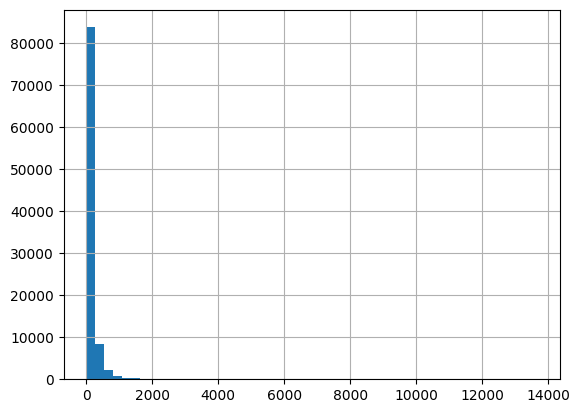

In [41]:
rfm["monetary"].hist(bins=50)

- Distributions verified before RFM scoring
- Skewness persists, so quantile-based binning is appropriate

In [47]:
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1])

In [48]:
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4])

In [49]:
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1,2,3,4])

In [50]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [51]:
rfm.head()

,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,161,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,164,4,1,1,411
2,0000f46a3911fa3c0805444483337064,1,86.22,586,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337,2,1,4,214


In [52]:
rfm["RFM_score"].value_counts().head()

RFM_score
444    1861
344    1774
244    1682
232    1660
122    1632
Name: count, dtype: int64